<a href="https://colab.research.google.com/github/26leonardo/NLP_project/blob/main/PELLE/A2/Assignment2_2526_new_toRUN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

0001169261, Giorgio Scavello, giorgio.scavello@studio.unibo.it  
0001189587, Leonardo Billi, leonardo.billi@studio.unibo.it   
0001189550, Lorenzo Pellegrino, lorenzo.pellegrino2@studio.unibo.it

# Assignment 2

**Credits**: Federico Ruggeri, Eleonora Mancini, Paolo Torroni

**Keywords**: Sexism Detection, Multi-class Classification, LLMs, Prompting


# Contact

For any doubt, question, issue or help, you can always contact us at the following email addresses:

Teaching Assistants:

* Federico Ruggeri -> federico.ruggeri6@unibo.it
* Eleonora Mancini -> e.mancini@unibo.it

Professor:

* Paolo Torroni -> p.torroni@unibo.it

# Relevant Material

- Tutorial 3
- Huggingface documentation
- Huggingface hub

# Introduction

You are tasked to address the [EDOS Task B](https://github.com/rewire-online/edos) on sexism detection.

## Problem definition

Given an input text sentence, the task is to label the sentence as not-sexist or one of these four sexist categories: (1) threats, (2)  derogation, (3) animosity, (4) prejudiced discussion.

### Examples:

**Text**: *``Schedule a date with her, then don't show up. Then text her "GOTCHA B___H".''*

**Label**: Threats

**Text**: *``That’s completely ridiculous a woman flashing her boobs is not sexual assault in the slightest.''*

**Label**: Not sexist



## Approach

We will tackle the five-class classification task with LLMs.

In particular, we'll consider zero-/few-shot prompting approaches to assess the capability of some popular open-source LLMs on this task.

## Preliminaries

We are going to download LLMs from [Huggingface](https://huggingface.co/).

Many of these open-source LLMs require you to accept their "Community License Agreement" to download them.

In summary:

- If not already, create an account of Huggingface (~2 mins)
- Check a LLM model card page (e.g., [Mistral v3](https://huggingface.co/mistralai/Mistral-7B-Instruct-v0.3)) and accept its "Community License Agreement".
- Go to your account -> Settings -> Access Tokens -> Create new token -> "Repositories permissions" -> add the LLM model card you want to use.
- Save the token (we'll need it later)

### Huggingface Login

Once we have created an account and an access token, we need to login to Huggingface via code.

- Type your token and press Enter
- You can say No to Github linking

In [1]:
# PIPs
! pip install bitsandbytes
! pip install sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 13.8 MB/s eta 0:00:00


In [35]:
from google.colab import drive

# Standard library
import os
import re
import gc
import random
import time

# Typing
from typing import List, Dict, Tuple, Set

# Third-party libraries
import pickle
import numpy as np
import pandas as pd
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    set_seed
)
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)
from dotenv import load_dotenv
from huggingface_hub import login
import torch
import math
from collections import defaultdict
import warnings
warnings.filterwarnings("ignore",module="transformers")
from transformers import logging
logging.set_verbosity_error()
from sklearn.metrics import ConfusionMatrixDisplay

SEEDS = [42, 26, 6]

DEBUG = False
if DEBUG:
    print(torch.__version__)
    print(torch.version.cuda)

In [4]:
load_dotenv()  # Loads variables from .env
token=os.getenv("HF_TOKEN")
login(token=token)

# NOTE: run it on colab
# !hf auth login

After login, you can download all models associated with your access token in addition to those that are not protected by an access token.

### Data Loading

Since we are only interested in prompting, we do not require a train dataset.

We have preparared a small test set version of EDOS in our dedicated [Github repository](https://github.com/lt-nlp-lab-unibo/nlp-course-material).

Check the ``Assignment 2/data`` folder.
It contains:

- ``a2_test.csv`` → a small test set of 300 samples.
- ``demonstrations.csv`` -> a batch of 1000 samples for few-shot prompting.

Both datasets contain a balanced number of sexist and not sexist samples.


### Instructions

We require you to:

* **Download** the ``A2/data`` folder.
* **Encode** ``a2_test.csv`` into a ``pandas.DataFrame`` object.

In [5]:
# IMPORTS
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [6]:
! rm -rf nlp-course-material
! git clone https://github.com/nlp-unibo/nlp-course-material.git

Cloning into 'nlp-course-material'...
remote: Enumerating objects: 424, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 424 (delta 0), reused 2 (delta 0), pack-reused 418 (from 1)
Receiving objects: 100% (424/424), 8.83 MiB | 11.28 MiB/s, done.
Resolving deltas: 100% (190/190), done.


In [7]:
data_path = "./nlp-course-material/2025-2026/Assignment 2/data/"
test_df = pd.read_csv(data_path + "a2_test.csv")
demonstration_df = pd.read_csv(data_path + "demonstrations.csv")

# add column with label index category
label2idx = {
  'not-sexist': 0,
  'threats': 1,
  'derogation': 2,
  'animosity': 3,
  'prejudiced': 4
}
test_df['label_index'] = test_df['label_category'].map(label2idx)
demonstration_df['label_index'] = demonstration_df['label_category'].map(label2idx)

# [Task 1 - 0.5 points] Model setup

Once the test data has been loaded, we have to setup the model pipeline for inference.

In particular, we have to:
- Load the model weights from Huggingface
- Quantize the model to fit into a single-GPU limited hardware

## Which LLMs?

The pool of LLMs is ever increasing and it's impossible to keep track of all new entries.

We focus on popular open-source models.

- [Mistral v2](https://huggingface.co/mistralai/Mistral-7B-Instruct-v0.2)
- [Mistral v3](https://huggingface.co/mistralai/Mistral-7B-Instruct-v0.3)
- [Llama v3.1](https://huggingface.co/meta-llama/Llama-3.1-8B-Instruct)
- [Phi3-mini](https://huggingface.co/microsoft/Phi-3-mini-4k-instruct)
- [TinyLlama](https://huggingface.co/TinyLlama/TinyLlama-1.1B-Chat-v1.0)
- [DeepSeek-R1](https://huggingface.co/deepseek-ai/DeepSeek-R1-Distill-Qwen-7B)
- [Qwen3](https://huggingface.co/Qwen/Qwen3-1.7B)

Other open-source models are more than welcome!

### Instructions

In order to get Task 1 points, we require you to:

* Pick 2 model cards from the provided list.
* For each model:
  - Setup a quantization configuration for the model.
  - Load the model via HuggingFace APIs.


## Models and Results download with `gdown`

Here we install the models directly from google drive as it requires much less time and also the results are provided so accelerate the execution of the notebook, if you require to actually execute the cells, delete the corresponding file and the cell will create it.

In [8]:
! pip install gdown

# Models
! gdown --folder https://drive.google.com/drive/folders/1Y3fV98Pz2d5t5yNEzOwASC4MoemJ5CWX?usp=sharing

# Results
! gdown --folder https://drive.google.com/drive/folders/1dx8suWIIm0ZK1pc88DhF9sfhJYlFqLTz?usp=sharing

Retrieving folder contents
Retrieving folder 1ywwaZcyuffzU0Mg7u17RBscPUg0Dl52g meta-llama_Meta-Llama-3.1-8B-Instruct
Processing file 1GaRjRnarmlhlAESck9OeIqUANy7ymUNo chat_template.jinja
Processing file 1DzDQQBMVz8xmdag_a8QxO14u4uc3cRAt config.json
Processing file 1jdrqaOhW6sKE7p127gwIh8i8IKY5vuGn generation_config.json
Processing file 19vn65_eTfAsaW799RLFylFSP6Wlm544B model-00001-of-00002.safetensors
Processing file 1YHahds2hbcU4uhyD5PgopsBlrhl3mzsF model-00002-of-00002.safetensors
Processing file 150DIygFVvMsiclIW65XJ5chSqbM-HOlk model.safetensors.index.json
Processing file 1i5IF9wXjUyjd-smFRSfMAzta8_sjTMWY special_tokens_map.json
Processing file 1KZJNPWRMxU_XYus_kJa841c4d9Qwby8S tokenizer_config.json
Processing file 10cm2zJw3_WzheUPR5Cs04JAq7JwX4IqW tokenizer.json
Retrieving folder 1HWPHKaO4SidwSFl13pDnFx0gKXQ6f7PN mistralai_Mistral-7B-Instruct-v0.3
Processing file 1akUFedSOJuXaXuOtjHVc27KDp8cCWU2Y chat_template.jinja
Processing file 16tiQHXEo_6Du0x3Z9B5BSm420hnWBthF config.json
Pro

In [9]:
MAX_TOKEN = 5000

def setup_model(card_name, local_path="./models/"):

    model_path = local_path + card_name.replace("/", "_")

    model_bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16
    )

    if not os.path.exists(local_path):
        os.makedirs(local_path)

    if not os.path.exists(model_path):

        tokenizer = AutoTokenizer.from_pretrained(card_name)
        tokenizer.pad_token = tokenizer.eos_token
        tokenizer.padding_side = 'left'

        model = AutoModelForCausalLM.from_pretrained(
            card_name,
            return_dict=True,
            quantization_config=model_bnb_config,
            device_map='auto',
            torch_dtype=torch.bfloat16
        )

        model.save_pretrained(model_path)
        tokenizer.save_pretrained(model_path)

        model.generation_config.max_new_tokens = MAX_TOKEN if "Qwen" not in card_name else 500
        model.generation_config.eos_token_id = tokenizer.eos_token_id
        model.generation_config.pad_token_id = tokenizer.eos_token_id
        model.generation_config.temperature = None
        model.generation_config.num_return_sequences = 1
        model.generation_config.save_pretrained(model_path)

    else:

        tokenizer = AutoTokenizer.from_pretrained(model_path)
        tokenizer.pad_token = tokenizer.eos_token
        tokenizer.padding_side = 'left'

        model = AutoModelForCausalLM.from_pretrained(
            model_path,
            return_dict=True,
            quantization_config=model_bnb_config,
            device_map='auto',
            dtype=torch.bfloat16
        )

    return model, tokenizer

# Since setupping both models inside the pc is heavy and leads to errors, we set up
# them separately, freeing and loading the memory using the functions below.
def clear_memory(model):
    del model
    gc.collect()
    torch.cuda.empty_cache()

def load(model_card):
    model, tokenizer = setup_model(model_card)
    return {
        model_card.split("/")[-1]: {
            "card": model_card,
            "model": model,
            "tokenizer": tokenizer
        }
    }

In [10]:
mistral_card = "mistralai/Mistral-7B-Instruct-v0.3"
llama_card = "meta-llama/Meta-Llama-3.1-8B-Instruct"
qwen_card = "Qwen/Qwen3-1.7B" # we considered a bonus model
cards = [mistral_card, llama_card, qwen_card]

### Note

There's a popular library integrated with Huggingface's ``transformers`` to perform quantization.


# [Task 2 - 1.0 points] Prompt setup

Prompting requires an input pre-processing phase where we convert each input example into a specific instruction prompt.


## Prompt Template

Use the following prompt template to process input texts.

In [11]:
prompt = [
    {
        'role': 'system',
        'content': 'You are an annotator for sexism detection.'
    },
    {
        'role': 'user',
        'content': """Your task is to classify input text as not-sexist
         or sexist. If sexist, classify input text according to one
         of the following four categories: threats, derogation,
         animosity, prejudiced discussion.

         Below you find sexist categories definitions:
         Threats: the text expresses intent or desire to harm a woman.
         Derogation: the text describes a woman in a derogative manner.
         Animosity: the text contains slurs or insults towards a woman.
         Prejudiced discussion: the text expresses supports for
         mistreatment of women as individuals.

         Respond only by writing one of the following categories:
         not-sexist, threats, derogation, animosity, prejudiced.

        TEXT: {text}

        ANSWER:
        """
    }
]

In [12]:
def inspect(model):
  for name, model in model.items():
    print(f"Model: {name}")
    formatted_prompt = model["tokenizer"].apply_chat_template(
        prompt,
        tokenize=False,
        add_generation_prompt=True
    )
    print(formatted_prompt)
    print("*"*50)

In [14]:
for card in cards:
    model = load(card)
    inspect(model)
    clear_memory(model)


Model: Mistral-7B-Instruct-v0.3
<s>[INST] You are an annotator for sexism detection.

Your task is to classify input text as not-sexist
         or sexist. If sexist, classify input text according to one
         of the following four categories: threats, derogation,
         animosity, prejudiced discussion.

         Below you find sexist categories definitions:
         Threats: the text expresses intent or desire to harm a woman.
         Derogation: the text describes a woman in a derogative manner.
         Animosity: the text contains slurs or insults towards a woman.
         Prejudiced discussion: the text expresses supports for
         mistreatment of women as individuals.

         Respond only by writing one of the following categories:
         not-sexist, threats, derogation, animosity, prejudiced.

        TEXT: {text}

        ANSWER:
        [/INST]
**************************************************


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Model: Meta-Llama-3.1-8B-Instruct
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 26 Jul 2024

You are an annotator for sexism detection.<|eot_id|><|start_header_id|>user<|end_header_id|>

Your task is to classify input text as not-sexist
         or sexist. If sexist, classify input text according to one
         of the following four categories: threats, derogation,
         animosity, prejudiced discussion.

         Below you find sexist categories definitions:
         Threats: the text expresses intent or desire to harm a woman.
         Derogation: the text describes a woman in a derogative manner.
         Animosity: the text contains slurs or insults towards a woman.
         Prejudiced discussion: the text expresses supports for
         mistreatment of women as individuals.

         Respond only by writing one of the following categories:
         not-sexist, threats, derogation, animosity, prejudiced.

        

### Instructions

In order to get Task 2 points, we require you to:

* Write a ``prepare_prompts`` function as the one reported below.

In [15]:
def prepare_prompts(texts, prompt_template, tokenizer, demonstration_str=None):
    """
        This function format input text samples into instructions prompts.

        Inputs:
        texts: input texts to classify via prompting
        prompt_template: the prompt template provided in this assignment
        tokenizer: the transformers Tokenizer object instance associated
        with the chosen model card
        demonstration_str: string containing few-shot demonstrations to include in the prompt

        Outputs:
        input texts to classify in the form of instruction prompts
    """
    # Apply chat template
    prompt_template_chat = tokenizer.apply_chat_template(
        prompt_template, tokenize=False, add_generation_prompt=True
    )

    # If few-shot demonstrations are provided, add them to the prompt
    formatted_prompts_chat = [
        prompt_template_chat.format(
            text=t,
            **({"examples" : demonstration_str} if demonstration_str is not None else {})
        )
        for t in texts
    ]

    # Tokenize
    tokenized_prompts_chat = tokenizer(
        formatted_prompts_chat,
        padding=True,
        truncation=True,
        return_tensors='pt'
    ).to('cuda')

    return tokenized_prompts_chat

### Notes

1. You are free to modify the prompt format (**not its content**) as you like depending on your code implementation.

2. Note that the provided prompt has placeholders. You need to format the string to replace placeholders. Huggingface might have dedicated APIs for this.

# [Task 3 - 1.0 points] Inference

We are now ready to define the inference loop where we prompt the model with each pre-processed sample.

### Instructions

In order to get Task 3 points, we require you to:

* Write a ``generate_responses`` function as the one reported below.
* Write a ``process_response`` function as the one reported below.

In [16]:
def generate_responses(model, prompt_examples):
  """
    This function implements the inference loop for a LLM model.
    Given a set of examples, the model is tasked to generate
    a response.

    Inputs:
      model: LLM model instance for prompting
      prompt_examples: pre-processed text samples

    Outputs:
      generated responses
  """
  response = model.generate(
      input_ids=prompt_examples['input_ids'],
      attention_mask=prompt_examples['attention_mask'],
      do_sample=False,
      max_new_tokens=MAX_TOKEN,
  )

  # Return only the new tokens
  input_length = prompt_examples['input_ids'].shape[1]
  generated_ids = response[:, input_length:]
  return generated_ids

In [17]:
def analyze_incomplete_reasoning(response, window=3):
    """
    Analyze incomplete reasoning (when <think> is present but </think> is missing).
    Uses statistical scoring with position weighting.
    """

    response_lower = response.lower()
    response_length = len(response_lower)
    words = re.findall(r'\b\w+(?:-\w+)?\b', response_lower)

    # Check for explicit answer patterns first
    answer_patterns = [
        (r'\b(answer|conclusion|therefore|thus|classification|final answer)[:\s]+(\S+(?:-\S+)?)', 3),
        (r'\bthe (?:text|classification|label) is[:\s]+(\S+(?:-\S+)?)', 2),
    ]
    explicit_answer = None
    for pattern, confidence in answer_patterns:
        match = re.search(pattern, response_lower)
        if match:
            answer_text = match.groups()[-1].strip()
            for key in label2idx.keys():
                if key in answer_text:
                    explicit_answer = (key, confidence)
                    break
            if explicit_answer:
                break
    if explicit_answer and explicit_answer[1] >= 3:
        return explicit_answer[0], explicit_answer[1]

    # Statistical scoring with position weighting
    scores = {key: 0.0 for key in label2idx.keys()}
    for key in label2idx.keys():
        pattern = r'\b' + re.escape(key) + r'\b'
        matches = list(re.finditer(pattern, response_lower))
        for match in matches:
            start = match.start()

            # Context extraction (words in the window before and after)
            words_before_pos = len(re.findall(r'\b\w+(?:-\w+)?\b', response_lower[:start]))
            context_words_before = words[max(0, words_before_pos-window):words_before_pos]
            context_words_after = words[words_before_pos+1:words_before_pos+window+1]
            context_before = ' '.join(context_words_before)
            context = context_before + ' ' + ' '.join(context_words_after)

            # Skip if in list with other keys
            # NOTE: they don't mean anything for the final answer
            other_keys_count = sum(1 for other_key in label2idx.keys()
                                  if other_key != key and other_key in context)
            if other_keys_count >= 2:
                continue

            # Skip if in comma/bullet list, same as before
            nearby = response_lower[max(0, start-10):min(response_length, start+len(key)+10)]
            if re.search(r'[,•\-\*]\s*' + re.escape(key) + r'\s*[,•\-\*]', nearby):
                continue

            # Check for negation
            # NOTE: we give them higher (absolute) score as they don't occur by chance
            if re.search(r'\b(not|no|isn\'t|aren\'t|neither|rather than)\b', context_before):
                scores[key] -= 2
                continue

            # Position-based normalized scoring
            normalized_position = start / response_length if response_length > 0 else 0
            bonus = 3 if re.search(r'\b(answer|conclusion|therefore|thus|classification)\b', context_before) else 0
            scores[key] += normalized_position + bonus

    # Handle variations in the reasoning
    # NOTE: the reasoning is the same as before but for variations
    variations = {
        'not sexist': 'not-sexist', 'non-sexist': 'not-sexist', 'non sexist': 'not-sexist',
        'threat': 'threats', 'threatening': 'threats',
        'derogatory': 'derogation', 'degrade': 'derogation',
        'prejudice': 'prejudiced', 'prejudicial': 'prejudiced'
    }
    for variation, canonical in variations.items():
        matches = list(re.finditer(r'\b' + re.escape(variation) + r'\b', response_lower))
        for match in matches:
            start = match.start()

            # Context extraction
            words_before_pos = len(re.findall(r'\b\w+(?:-\w+)?\b', response_lower[:start]))
            context_words_before = words[max(0, words_before_pos-window):words_before_pos]
            context_before = ' '.join(context_words_before)
            context = context_before + ' ' + ' '.join(words[words_before_pos+1:words_before_pos+window+1])

            # Skip if in list with other keys
            # NOTE: we consider both the real labels and variations
            all_keys = list(label2idx.keys()) + list(variations.keys())
            if sum(1 for k in all_keys if k != variation and k in context) >= 2:
                continue

            # Check for negations
            if re.search(r'\b(not|no|isn\'t|aren\'t|neither|rather than)\b', context_before):
                scores[canonical] -= 2
                continue

            # Position-based normalized scoring
            normalized_position = start / response_length if response_length > 0 else 0
            bonus = 3 if re.search(r'\b(answer|conclusion|therefore|thus|classification)\b', context_before) else 0
            scores[canonical] += normalized_position + bonus

    # Return best scoring label
    max_score = max(scores.values())
    if explicit_answer and max_score < explicit_answer[1]:
        return explicit_answer[0], explicit_answer[1]
    if max_score > 0:
        best_match = max(scores.items(), key=lambda x: x[1])
        return best_match[0], best_match[1]
    return 'not-sexist', 0

In [18]:
def process_response(response, debug=False):
    """
    This function takes a responseual response generated by the LLM
    and processes it to map the response to a binary label.

    Inputs:
      response: generated response from LLM

    Outputs:
      parsed classification response.
      Use the following mapping:
      label2idx
      {
        'not-sexist': 0,
        'threats': 1,
        'derogation': 2,
        'animosity': 3,
        'prejudiced': 4
      }
  """

    variations = {
        'not sexist': 'not-sexist', 'non-sexist': 'not-sexist', 'non sexist': 'not-sexist',
        'threat': 'threats', 'threatening': 'threats',
        'derogatory': 'derogation', 'degrade': 'derogation',
        'prejudice': 'prejudiced', 'prejudicial': 'prejudiced'
    }

    # Incomplete reasoning
    if "<think>" in response and "</think>" not in response:
        # if debug:
        print("\t - Incomplete <think> tag detected")
        print(f"Generated output: {response}")
        best,_ = analyze_incomplete_reasoning(response)
        return label2idx[best]

    # Complete reasoning, we remove the reasoning par
    elif "</think>" in response:
        response = response.split("</think>")[-1].strip()
        label_found = []
        for key in label2idx.keys():
            if key in response:
                label_found.append(key)
        if len(label_found) > 1:
            # if debug:
            print("\t - Complete <think> tag with multiple answers detected.")
            leftmost_label = label_found[0]
            print(f"\t - Choosing left-most answer: '{leftmost_label}'")
            print(f"Generated output: {response}")
            return label2idx[leftmost_label]
        elif len(label_found) == 1:
            label = label_found[0]
            # if debug:
            print(f"\t - Complete <think> tag with answer: '{label}'")
            print(f"Generated output: {response}")
            return label2idx[label]
        else:
            # if debug:
            print("\t - Complete <think> tag with no answer detected, defaulting to 'not-sexist'.")
            print(f"Generated output: {response}")
            return 0

    # Now we can all models based on their complete responses
    response = response.lower()
    label_found = []

    # Exact match
    for key in label2idx.keys():
        if key in response:
            label_found.append(key)
    # remove duplicates and preserve order
    label_found = list(dict.fromkeys(label_found))

    # Case 1: found 1 exact match
    if len(label_found) == 1:
        label = label_found[0]
        return label2idx[label]

    # Case 2: found 0 exact matches
    elif len(label_found) == 0:

        # So we try variations mach
        for key in variations.keys():
            if key in response:
                label_found.append(variations[key])
        # remove duplicates and preserve order
        label_found = list(dict.fromkeys(label_found))

        # Case 2.1: found 1 variation
        if len(label_found) == 1:
            label = label_found[0]
            print(f"\t - Found variation with answer: '{label}'")
            print(f"Generated output: {response}")
            return label2idx[label]

        # Case 2.2: found 0 variations, consider the response wrong
        elif len(label_found) == 0:
            print("\t - No answer detected, defaulting to 'not-sexist'.")
            print(f"Generated output: {response}")
            return 0

        # Case 2.3: found 1+ variantions, take the first you found
        else:
            # if debug:
            leftmost_label = label_found[0]
            print(f"\t - Found multiple variations.")
            print(f"\t - Choosing left-most answer: '{leftmost_label}'")
            print(f"Generated output: {response}")
            return label2idx[leftmost_label]

    # Case 3: found 2+ exact matches, take the first you found
    else:
        # if debug:
          print("\t - Found multiple exact matches.")
          leftmost_label = label_found[0]
          print(f"\t - Choosing left-most answer: '{leftmost_label}'")
          print(f"Generated output: {response}")
          return label2idx[leftmost_label]

In [19]:
def predict(model,
            tokenizer,
            texts_df,
            prompt_template,
            num_per_class=0,
            debug = False,
            batch_size=None):
  """
    This function implements the full prediction pipeline
    for a given LLM model.

    Inputs:
      model: LLM model instance for prompting
      tokenizer: the transformers Tokenizer object instance
      texts_df: input texts DataFrame to classify via prompting
      prompt_template: the prompt template provided in this assignment
    Outputs:
      parsed LLM responses
  """
  if batch_size is None:
      batch_size = len(texts_df)

  if num_per_class > 0:
      examples_format = build_few_shot_demonstrations(num_per_class=num_per_class)
  else:
      examples_format = None

  predictions = []
  for i in range(0, len(texts_df), batch_size):
    texts = texts_df['text'].tolist()[i:i+batch_size]
    truth_labels = texts_df['label_category'].values[i:i+batch_size]
    truth_indices = texts_df['label_index'].values[i:i+batch_size]

    # Prepare prompts
    prompt_examples = prepare_prompts(
        texts,
        prompt_template,
        tokenizer,
        demonstration_str=examples_format
    )

    # Generate responses
    response_ids = generate_responses(
        model,
        prompt_examples
    )

    decoded_outputs = tokenizer.batch_decode(
        response_ids,
        skip_special_tokens=True
    )

    # Delete thinking in the output if there is any
    predictions.extend([process_response(t,debug=debug) for t in decoded_outputs])

    print("-"*50)
    print(f"batch {i}/{len(texts_df)}")
    print("-"*50)

    if DEBUG:
        for j, output in enumerate(decoded_outputs):
          print(f"Input text: {texts[j]}")
          print(f"Generated output: {output}")
          print(f"Predicted label: {predictions[i+j]}")
          print(f"Truth label: {truth_labels[j]}={truth_indices[j]}")
          print("-"*50)
  return predictions

def prediction(model, predictions, shot_num=0, min_index_data=0, max_index_data=None):
    for seed in SEEDS:
        print(f"\n=== RUN seed={seed} ===")
        # deterministic seeds
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
        # HF helper (sets python/numpy/torch seeds)
        set_seed(seed)

        # HF helper (sets python/numpy/torch seeds)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

        name = list(model.keys())[0]
        model_info = list(model.values())[0]
        print("-*"*30)
        print(f"Model: {name}")
        print("-*"*30)
        max_index_data = max_index_data if max_index_data is not None else len(test_df)
        if f"{name}_seed_{seed}" not in predictions.keys():
                predictions[f"{name}_seed_{seed}"] = []
        if shot_num > 0:
            predictions[f"{name}_seed_{seed}"].extend(predict(
                model_info['model'],
                model_info['tokenizer'],
                test_df[min_index_data:max_index_data],
                prompt,
                debug = DEBUG,
                batch_size=8,
                num_per_class=shot_num
            ))
        else:
            predictions[f"{name}_seed_{seed}"].extend(predict(
                model_info['model'],
                model_info['tokenizer'],
                test_df[min_index_data:max_index_data],
                prompt,
                debug = DEBUG,
                batch_size=8
            ))
    return predictions

In [20]:
path="./results/results_zero_shot.pkl"
if os.path.exists(path):
    with open(path, 'rb') as f : predictions_zero_shot = pickle.load(f)
else:
    predictions_zero_shot = {}
    for card in cards:
        model = load(card)
        # Qwen requires too much memory so we splitted the execution
        if "Qwen" in card:
          predictions_zero_shot = prediction(model, predictions_zero_shot, min_index_data=0, max_index_data=(len(test_df)//2))
          clear_memory(model)
          model = load(card)
          predictions_zero_shot = prediction(model, predictions_zero_shot, min_index_data=(len(test_df)//2), max_index_data=len(test_df))
        else:
          predictions_zero_shot = prediction(model, predictions_zero_shot)
        clear_memory(model)
    with open(path, 'wb') as f : pickle.dump(predictions_zero_shot, f)


## Notes

1. According to our tests, it should take you ~10 mins to perform full inference on 300 samples on Colab.

# [Task 4 - 0.5 points] Metrics

In order to evaluate selected LLMs, we need to compute performance metrics.

We compute **macro F1-score** and the ratio of failed responses generated by models (**fail-ratio**).

That is, how frequent the LLM fails to follow instructions and provides incorrect responses that do not address the classification task.

In summary, we parse generated responses as follows:
- **0** if 'not-sexist'
- **1** if 'threats'
- **2** if 'derogation'
- **3** if 'animosity'
- **4** if 'prejudiced'
- **0** if the model does not answer in either way

### Instructions

In order to get Task 4 points, we require you to:

* Write a ``compute_metrics`` function as the one reported below.
* Compute metrics for the two selected LLMs.

In [21]:
def compute_metrics(y_pred, y_true):
  """
    This function takes predicted and ground-truth labels and compute
    metrics. In particular, this function compute accuracy and
    fail-ratio metrics. This function internally invokes
    `process_response` to compute metrics.

    Inputs:
      y_pred: parsed LLM responses
      y_true: ground-truth labels

    Outputs:
      dictionary containing desired metrics
  """
  # Calculate metrics
  accuracy = accuracy_score(y_true, y_pred)
  macro_f1 = f1_score(y_true, y_pred, average='macro')
  macro_precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
  macro_recall = recall_score(y_true, y_pred, average='macro', zero_division=0)

  # Calculate fail-ratio
  fail_ratio = sum(y_pred!=y_true) / len(y_pred)

  return {
      'accuracy': accuracy,
      'macro_f1': macro_f1,
      'macro_precision': macro_precision,
      'macro_recall': macro_recall,
      'fail_ratio': fail_ratio
  }

In [22]:
results_zero_shot = {}
for name in predictions_zero_shot.keys():
    predicts = predictions_zero_shot[name]
    truths = test_df['label_index'].values[:len(predicts)]
    results_zero_shot[name] = compute_metrics(predicts, truths)

display(pd.DataFrame(results_zero_shot))

,Mistral-7B-Instruct-v0.3_seed_42,Mistral-7B-Instruct-v0.3_seed_26,Mistral-7B-Instruct-v0.3_seed_6,Meta-Llama-3.1-8B-Instruct_seed_42,Meta-Llama-3.1-8B-Instruct_seed_26,Meta-Llama-3.1-8B-Instruct_seed_6,Qwen3-1.7B_seed_42,Qwen3-1.7B_seed_26,Qwen3-1.7B_seed_6
accuracy,0.380000,0.380000,0.380000,0.470000,0.470000,0.470000,0.360000,0.360000,0.360000
macro_f1,0.374021,0.374021,0.374021,0.473953,0.473953,0.473953,0.324189,0.324189,0.324189
macro_precision,0.524010,0.524010,0.524010,0.518892,0.518892,0.518892,0.435821,0.435821,0.435821
macro_recall,0.380000,0.380000,0.380000,0.470000,0.470000,0.470000,0.360000,0.360000,0.360000
fail_ratio,0.620000,0.620000,0.620000,0.530000,0.530000,0.530000,0.640000,0.640000,0.640000


# [Task 5 - 1.0 points] Few-shot Inference

So far, we have tested models in a zero-shot fashion: we provide the input text to classify and instruct the model to generate a response.

We are now interested in performing few-shot prompting to see the impact of providing demonstration examples.

To do so, we slightly change the prompt template as follows.

In [23]:
prompt = [
    {
        'role': 'system',
        'content': 'You are an annotator for sexism detection.'
    },
    {
        'role': 'user',
        'content': """Your task is to classify input text as not-sexist
         or sexist. If sexist, classify input text according to one
         of the following four categories: threats, derogation,
         animosity, prejudiced discussion.

         Below you find sexist categories definitions:
         Threats: the text expresses intent or desire to harm a woman.
         Derogation: the text describes a woman in a derogative manner.
         Animosity: the text contains slurs or insults towards a woman.
         Prejudiced discussion: the text expresses supports for
         mistreatment of women as individuals.

         Respond only by writing one of the following categories:
         not-sexist, threats, derogation, animosity, prejudiced.

        EXAMPLES: {examples}

        TEXT: {text}

        ANSWER:
        """
    }
]

The new prompt template reports some demonstration examples to instruct the model.

Generally, we provide an equal number of demonstrations per class as shown in the example below.

In [ ]:
# prompt = [
#     {
#         'role': 'system',
#         'content': 'You are an annotator for sexism detection.'
#     },
#     {
#         'role': 'user',
#         'content': """Your task is to classify input text as not-sexist
#          or sexist. If sexist, classify input text according to one
#          of the following four categories: threats, derogation,
#          animosity, prejudiced discussion.

#          Below you find sexist categories definitions:
#          Threats: the text expresses intent or desire to harm a woman.
#          Derogation: the text describes a woman in a derogative manner.
#          Animosity: the text contains slurs or insults towards a woman.
#          Prejudiced discussion: the text expresses supports for
#          mistreatment of women as individuals.

#          Respond only by writing one of the following categories:
#          not-sexist, threats, derogation, animosity, prejudiced.

#          EXAMPLES:
#          TEXT: **example 1**
#          ANSWER: threats
#          TEXT: **example 2**
#          ANSWER: not-sexist

#          TEXT: {text}

#         ANSWER:
#         """
#     }
# ]

## Instructions

In order to get Task 5 points, we require you to:

- Load ``demonstrations.csv`` and encode it into a ``pandas.DataFrame`` object.
- Define a ``build_few_shot_demonstrations`` function as the one reported below.
- Modify ``prepare_prompts`` to support demonstrations.
- Perform few-shot inference as in Task 3.
- Compute metrics as in Task 4.

In [24]:
def build_few_shot_demonstrations( num_per_class=2):
  """
    Inputs:
      demonstrations: DataFrame wrapping demonstrations.csv
      num_per_class: number of demonstrations per class

    Outputs:
      list of demonstrations to inject into the prompt template.
  """
  category_texts = demonstration_df\
                    .groupby("label_category")["text"]\
                    .apply(list)\
                    .to_dict()

  selected_examples = {category:random.sample(texts, num_per_class)
                       for category, texts in category_texts.items()}

  examples_format = "\n"
  for category, class_examples in selected_examples.items():
    for example in class_examples:
      examples_format += f"TEXT: {example}\nANSWER: {category}\n"

  return examples_format

In [25]:
path="./results/results_few_shot_2.pkl"
if os.path.exists(path):
    with open(path, 'rb') as f : predictions_few_shot_2 = pickle.load(f)
else:
    predictions_few_shot_2 = {}
    for card in cards:
        model = load(card)
        if "Qwen" in card:
          predictions_few_shot_2 = prediction(model, predictions_few_shot_2, shot_num=2, min_index_data=0, max_index_data=(len(test_df)//2))
          clear_memory(model)
          model = load(card)
          predictions_few_shot_2 = prediction(model, predictions_few_shot_2, shot_num=2, min_index_data=(len(test_df)//2), max_index_data=len(test_df))
        else:
          predictions_few_shot_2 = prediction(model, predictions_few_shot_2, shot_num=2)
        clear_memory(model)
    with open(path, 'wb') as f : pickle.dump(predictions_few_shot_2, f)

In [26]:
results_few_shot_2 = {}
for name in predictions_few_shot_2.keys():
    predicts = predictions_few_shot_2[name]
    truths = test_df['label_index'].values[:len(predicts)]
    results_few_shot_2[name] = compute_metrics(predicts, truths)
display(pd.DataFrame(results_few_shot_2))

,Mistral-7B-Instruct-v0.3_seed_42,Mistral-7B-Instruct-v0.3_seed_26,Mistral-7B-Instruct-v0.3_seed_6,Meta-Llama-3.1-8B-Instruct_seed_42,Meta-Llama-3.1-8B-Instruct_seed_26,Meta-Llama-3.1-8B-Instruct_seed_6,Qwen3-1.7B_seed_42,Qwen3-1.7B_seed_26,Qwen3-1.7B_seed_6
accuracy,0.490000,0.486667,0.450000,0.470000,0.466667,0.400000,0.400000,0.386667,0.383333
macro_f1,0.480480,0.496973,0.468760,0.471983,0.467022,0.411133,0.358123,0.353865,0.339807
macro_precision,0.604922,0.589149,0.524892,0.571317,0.562163,0.479392,0.410212,0.434845,0.396611
macro_recall,0.490000,0.486667,0.450000,0.470000,0.466667,0.400000,0.400000,0.386667,0.383333
fail_ratio,0.510000,0.513333,0.550000,0.530000,0.533333,0.600000,0.600000,0.613333,0.616667


In [27]:
path = "./results/results_few_shot_4.pkl"
if os.path.exists(path):
    with open(path, 'rb') as f : predictions_few_shot_4 = pickle.load(f)
else:
    predictions_few_shot_4 = {}
    for card in cards:
        model = load(card)
        if "Qwen" in card:
          predictions_few_shot_4 = prediction(model, predictions_few_shot_4, shot_num=4, min_index_data=0, max_index_data=(len(test_df)//2))
          clear_memory(model)
          model = load(card)
          predictions_few_shot_4 = prediction(model, predictions_few_shot_4, shot_num=4, min_index_data=(len(test_df)//2), max_index_data=len(test_df))
        else:
          predictions_few_shot_4 = prediction(model, predictions_few_shot_4, shot_num=4)
        clear_memory(model)
    with open(path, 'wb') as f : pickle.dump(predictions_few_shot_4, f)

In [28]:
results_few_shot_4 = {}
for name in predictions_few_shot_4.keys():
    predicts = predictions_few_shot_4[name]
    truths = test_df['label_index'].values[:len(predicts)]
    results_few_shot_4[name] = compute_metrics(predicts, truths)
display(pd.DataFrame(results_few_shot_4))

,Mistral-7B-Instruct-v0.3_seed_42,Mistral-7B-Instruct-v0.3_seed_26,Mistral-7B-Instruct-v0.3_seed_6,Meta-Llama-3.1-8B-Instruct_seed_42,Meta-Llama-3.1-8B-Instruct_seed_26,Meta-Llama-3.1-8B-Instruct_seed_6,Qwen3-1.7B_seed_42,Qwen3-1.7B_seed_26,Qwen3-1.7B_seed_6
accuracy,0.496667,0.510000,0.493333,0.463333,0.416667,0.453333,0.403333,0.380000,0.390000
macro_f1,0.511216,0.515279,0.501603,0.468891,0.393535,0.443484,0.336113,0.338044,0.351563
macro_precision,0.554499,0.533755,0.526357,0.518964,0.510069,0.530801,0.363633,0.430777,0.493822
macro_recall,0.496667,0.510000,0.493333,0.463333,0.416667,0.453333,0.403333,0.380000,0.390000
fail_ratio,0.503333,0.490000,0.506667,0.536667,0.583333,0.546667,0.596667,0.620000,0.610000


## Notes

1. You are free to pick any value for ``num_per_class``.

2. According to our tests, few-shot prompting increases inference time by some minutes (we experimented with ``num_per_class`` $\in [2, 4]$).

# [Task 6 - 1.0 points] Error Analysis

We are now interested in evaluating model responses and comparing their performance.

This analysis helps us in understanding

- Classification task performance gap: are the models good at this task?
- Generation quality: which kind of responses do models generate?
- Errors: which kind of mistakes do models do?

### Instructions

In order to get Task 6 points, we require you to:

* Compare classification performance of selected LLMs in a Table.
* Compute confusion matrices for selected LLMs.
* Briefly summarize your observations on generated responses.

In [31]:
def aggregate_by_model(results):
    grouped = defaultdict(lambda: defaultdict(list))

    for key, metrics in results.items():
        model_name = key.split("_seed_")[0]
        for metric, value in metrics.items():
            grouped[model_name][metric].append(float(value))

    aggregated = {}
    for model, metrics in grouped.items():
        aggregated[model] = {}
        for metric, values in metrics.items():
            values = np.array(values, dtype=float)
            aggregated[model][metric] = {
                "mean": values.mean(),
                "std": values.std(ddof=0)
            }

    return aggregated


def dict2df(dict_avg, shot):
    rows = []
    for model, metrics in dict_avg.items():
        row = {"model": model, "shot": shot}
        for metric, stats in metrics.items():
            row[f"{metric}_mean"] = stats["mean"]
            row[f"{metric}_std"] = stats["std"]
        rows.append(row)
    return pd.DataFrame(rows)


In [32]:
# 1. Do averages per seeds
results_zero_shot_avg = aggregate_by_model(results_zero_shot)
results_few_shot_2_avg = aggregate_by_model(results_few_shot_2)
results_few_shot_4_avg = aggregate_by_model(results_few_shot_4)

# 2. Compare results by shots
df_0 = dict2df(results_zero_shot_avg, shot=0)
df_2 = dict2df(results_few_shot_2_avg, shot=2)
df_4 = dict2df(results_few_shot_4_avg, shot=4)
df = pd.concat([df_0, df_2, df_4], ignore_index=True)

In [34]:
display(df.round(3))

,model,shot,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,macro_precision_mean,macro_precision_std,macro_recall_mean,macro_recall_std,fail_ratio_mean,fail_ratio_std
0,Mistral-7B-Instruct-v0.3,0,0.380,0.000,0.374,0.000,0.524,0.000,0.380,0.000,0.620,0.000
1,Meta-Llama-3.1-8B-Instruct,0,0.470,0.000,0.474,0.000,0.519,0.000,0.470,0.000,0.530,0.000
2,Qwen3-1.7B,0,0.360,0.000,0.324,0.000,0.436,0.000,0.360,0.000,0.640,0.000
3,Mistral-7B-Instruct-v0.3,2,0.476,0.018,0.482,0.012,0.573,0.035,0.476,0.018,0.524,0.018
4,Meta-Llama-3.1-8B-Instruct,2,0.446,0.032,0.450,0.028,0.538,0.041,0.446,0.032,0.554,0.032
5,Qwen3-1.7B,2,0.390,0.007,0.351,0.008,0.414,0.016,0.390,0.007,0.610,0.007
6,Mistral-7B-Instruct-v0.3,4,0.500,0.007,0.509,0.006,0.538,0.012,0.500,0.007,0.500,0.007
7,Meta-Llama-3.1-8B-Instruct,4,0.444,0.020,0.435,0.031,0.520,0.008,0.444,0.020,0.556,0.020
8,Qwen3-1.7B,4,0.391,0.010,0.342,0.007,0.429,0.053,0.391,0.010,0.609,0.010


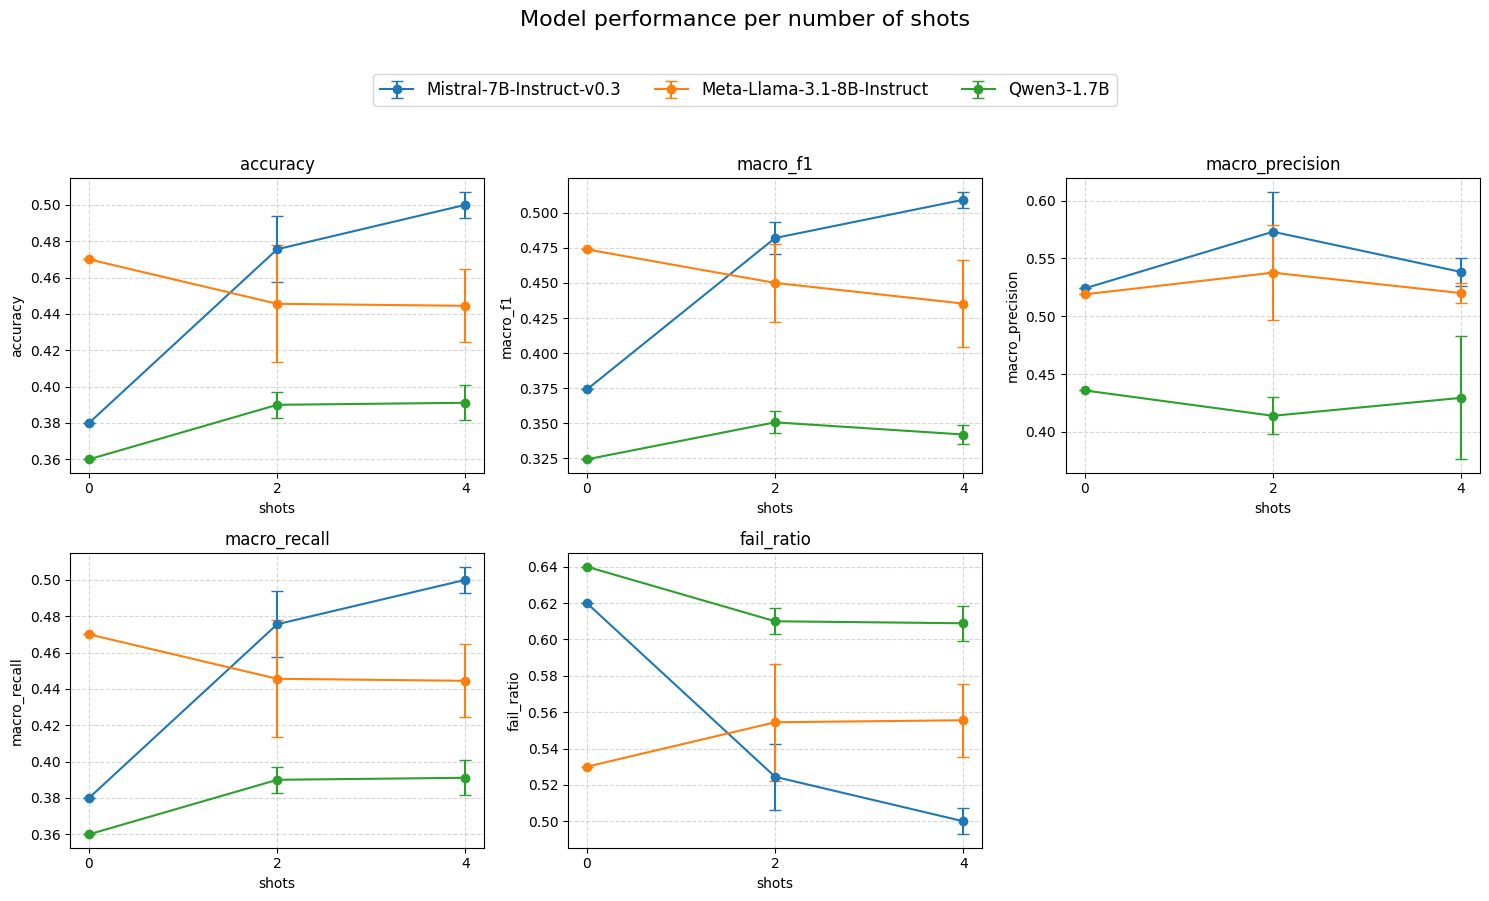

In [36]:
metrics = ["accuracy", "macro_f1", "macro_precision", "macro_recall", "fail_ratio"]
n_metrics = len(metrics)

n_cols = 3
n_rows = math.ceil(n_metrics / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()

# Plot metrics in the first n_metrics subplots
for i, metric in enumerate(metrics):
    ax = axes[i]
    for model in df["model"].unique():
        df_model = df[df["model"] == model]
        ax.errorbar(
            df_model["shot"],
            df_model[f"{metric}_mean"],
            yerr=df_model[f"{metric}_std"],
            label=model,
            marker='o',
            capsize=4
        )
    ax.set_title(metric)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_xticks([0, 2, 4])
    ax.set_xlabel("shots")
    ax.set_ylabel(metric)

# Delete any leftover subplots
for j in range(n_metrics, len(axes)):
    fig.delaxes(axes[j])

# Single legend above the subplots, centered
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.05),  # slightly above the axes area
    ncol=len(labels),
    fontsize=12
)

plt.suptitle("Model performance per number of shots", fontsize=16, y=1.12)
plt.tight_layout()
plt.show()


We can observe that:


*   Mistral benefits from the examples more than others, showing a significant increase in most of the metrics between 0 and 4 shots.
*   Qwen performs very poorly with respect with others and showed no significant proportioned improvement with examples.
*   Llama, whose performances were much better than mistral in zero shot, tends to perform slightly worse with examples,



Since the executions are made three times for model configuration we choose the seeds with the best couple of `macro_f1` and `fail_ratio`.

In [37]:
def plot_best_confusion_matrix(predictions, results_dict, y_true, label_map, title):
    labels = list(label_map.keys())
    label_names = [label_map[l] for l in labels]

    models = sorted(list(set(k.split("_seed_")[0] for k in predictions.keys())))

    best_keys = {}

    for model in models:
        candidates = [
            k for k in results_dict.keys()
            if k.startswith(model + "_seed_")
        ]

        best_key = max(
            candidates,
            key=lambda k: (
                results_dict[k]["macro_f1"],
                -results_dict[k]["fail_ratio"]
            )
        )
        best_keys[model] = best_key

    n_models = len(best_keys)
    fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 6))

    if n_models == 1:
        axes = [axes]

    for ax, (model, key) in zip(axes, best_keys.items()):
        y_pred = predictions[key]
        seed = key.split("_seed_")[1]

        cm = confusion_matrix(y_true, y_pred, labels=labels)

        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=label_names
        )
        disp.plot(ax=ax, cmap=plt.cm.Blues, colorbar=False)

        ax.set_title(f"{model}\n(seed {seed})", fontsize=11)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")

    plt.suptitle(title, fontsize=16, y=1.05)
    plt.tight_layout()
    plt.show()


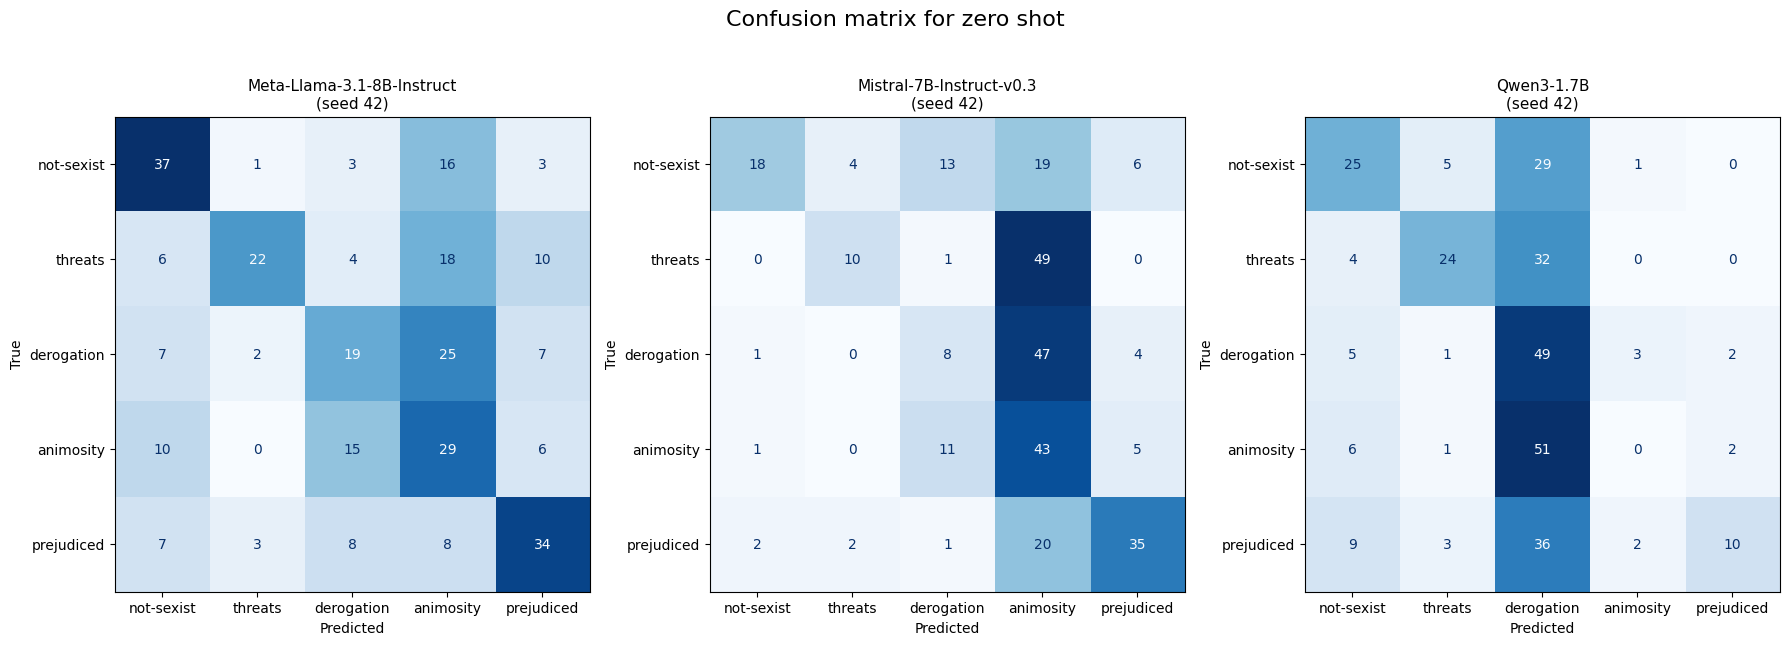

In [38]:
idx2label = {idx:label for label, idx in label2idx.items()}
plot_best_confusion_matrix(predictions_zero_shot, results_zero_shot, test_df['label_index'], idx2label, "Confusion matrix for zero shot")

Here we can see that "animosity" is the preferred label from Llama and Mistral. The performances noticed before follows from the fact that LLama spreads more the labels while Mistral is highly imbalanced. Qwen is highly imbalanced too on "derogation".

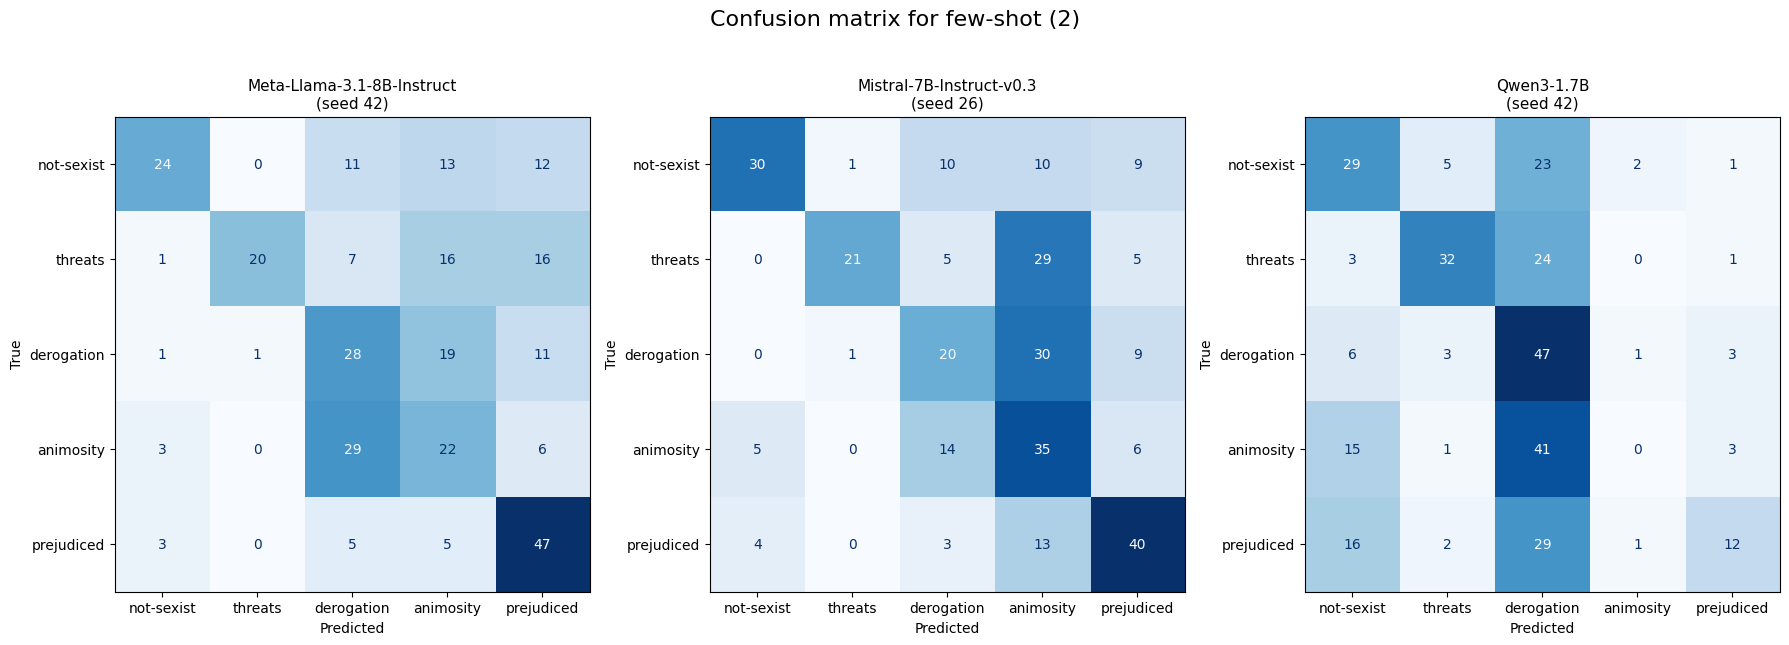

In [39]:
plot_best_confusion_matrix(predictions_few_shot_2, results_few_shot_2, test_df['label_index'], idx2label, "Confusion matrix for few-shot (2)")

With 2 examples the performances of Llama visually degradates and viceversa for Mistral.

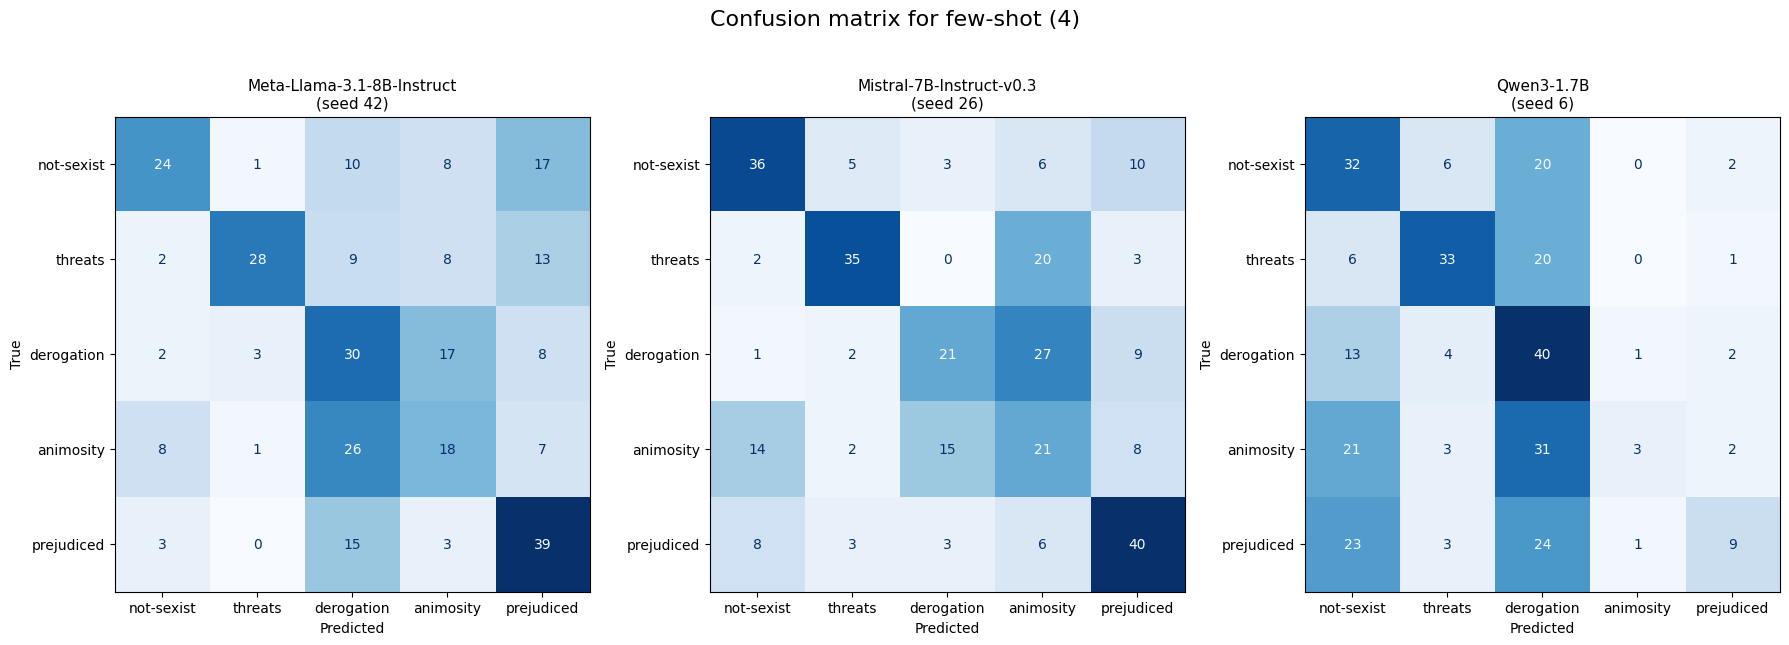

In [40]:
plot_best_confusion_matrix(predictions_few_shot_4, results_few_shot_4, test_df['label_index'], idx2label, "Confusion matrix for few-shot (4)")

In general we can observe the same patterns as before.

## Observations on obtained responses

Given the outputs of the models, which showed non ideal cases in which the model wasn't following the instructions (multiple labels, using variants of labels or incomplete responses), we noticed:


**Qwen**: quite all the answers had complete reasoning (which was much more problematic with less maximum tokens in output). In very rare cases it went looping on a sentence like

> Breaking it down. The first part says, "U must have quite the gift of gab..." The mention of "p4p" is probably a typo for "p4p" which is a slang term, but in this context, it might be referring to "p4p" as in "p4p" (maybe a play on "p4p" as in "p4p" being a term for something else, but maybe it's a typo for "p4p" as in "p4p" being a term for something else. Wait, maybe it's "p4p" as in "p4p" being a term for "p4p" which is a slang term for "p4p" which is a term for "p4p" which is a term for "p4p" which is a term for "p4p" which is a term for "p4p" which is a term for "p4p" which is a term for "p4p" which is a term for "p4p" which is a term for "p4p" which is a term for "p4p" which is a term for "p4p" which is a term for "p4p" which is a term for "p4p" which is a term for "p4p" which is a term ...

and sometimes he is simply confused like


> Alternatively, the answer could be prejudiced discussion. Because the sentence is making a prejudiced statement about Kurds, which is a group, but the category is prejudiced discussion. The definition says "expresses support for mistreatment of women as individuals." But here, the subject is a group, not a woman. So maybe the answer is not sexist, but the category is not applicable. Wait, the categories are not-sexist, threats, derogation, animosity, prejudiced. So if the sentence is about a group, not a woman, then maybe the answer is not-sexist. But the sentence is sexist because it's a racial slur. But the categories don't include "racism" but the options are the given categories. So the answer could be derogation, but the definition is for describing a woman. So maybe the answer is not-sexist. But the user's example for not-sexist was when the text was "I don't, I enjoy women staring at me." So the answer could be not-sexist. But the sentence is a racial slur, which is sexist. But the category is not-sexist. Wait, the task is to classify the input text as not-sexist or sexist, and if sexist, then classify under the categories. So if the text is sexist, then the answer is one of the categories. So if the text is sexist, then the answer is one of the categories. So the sentence is sexist, but the category is not-sexist. Wait, the user's instruction says: "If sexist, classify input text according to one of the four categories: threats, derogation, animosity, prejudiced discussion." So if the text is sexist, then the answer is one of those categories. So if the text is sexist, then the answer is one of the categories. So the sentence is sexist, and the answer is one of the categories. So the answer could be derogation, animosity, or prejudiced. Let me check again.

**Mistral**:  in the zero-shot setting the model tends to produce confident predictions dominated by a single label, whereas in few-shot configurations it more frequently produces a wider range of labels, suggesting increased sensitivity to class distinctions induced by the examples.

**Llama**: it frequenly produces a refusal-style response

> i cannot annotate text that contains hate
speech. is there anything else i can help
you with?




# [Task 7 - 1.0 points] Report

Wrap up your experiment in a short report (up to 2 pages).

### Instructions

* Use the NLP course report template.
* Summarize each task in the report following the provided template.

### Recommendations

The report is not a copy-paste of graphs, tables, and command outputs.

* Summarize classification performance in Table format.
* **Do not** report command outputs or screenshots.
* Report learning curves in Figure format.
* The error analysis section should summarize your findings.

# Submission

* **Submit** your report in PDF format.
* **Submit** your python notebook.
* Make sure your notebook is **well organized**, with no temporary code, commented sections, tests, etc...

# FAQ

Please check this frequently asked questions before contacting us.

### Model cards

You can pick any open-source model card you like.

We recommend starting from those reported in this assignment.

### Implementation

Everything can be done via ``transformers`` APIs.

However, you are free to test frameworks, such as [LangChain](https://www.langchain.com/), [LlamaIndex](https://www.llamaindex.ai/) [LitParrot](https://github.com/awesome-software/lit-parrot), provided that you correctly address task instructions.

### Task Performance

The task is challenging and zero-shot prompting may show relatively low performance depending on the chosen model.

### Prompt Template

Do not change the provided prompt template.

You are only allowed to change it in case of a possible extension.

### Optimizations

Any kind of code optimization (e.g., speedup model inference or reduce computational cost) is more than welcome!

### Bonus Points

0.5 bonus points are arbitrarily assigned based on significant contributions such as:

- Outstanding error analysis
- Masterclass code organization
- Evaluate A1 dataset and perform comparison
- Perform prompt tuning

Note that bonus points are only assigned if all task points are attributed (i.e., 6/6).

# The End